In [ ]:
Assignment of Machine Learning

In [ ]:
1.What is Machine Learning and why is it used for?

In [ ]:
ans: Machine Learning is a set of algorithms that allows a computer to find patterns in data and predict the outcomes.
     [ML= set of algorithm-computer-find pattern-predict outcome]
It is used to find pattern in large amount of dataset, to make acurate prediction, to make better decison.

In [ ]:
2.Define what is a function. Explain why a function is called a basic block of ML

In [ ]:
ans: A function is a mapping that relates an input variable to an output variable.
         y=f(x)  where, y- output/dependent variable
                        x- input/independent variable
                        f- mapping function 
         [output attributes=program(input attributes)]
It is called basic block of ML because the goal of every ML model is to learn the function between input features and output labels or predictions.

In [ ]:
3.Explain in own words what is supervised, unsupervised, and semi-supervised ML.

In [ ]:
ans: 1.Supervised ML : It uses labled data for traning to make predictions. It consist two types algorithm such as regression and classification.
example: Predicting student marks from how many hour they have studied
     2.Unsupervised ML: It uses unlabeled data for training to find patterns or groups in the data.
example: grouping customers based on shopping behavior (cash,card,upi)
     3.Semi-supervised ML: It combines supervised and unsupervised ML by using both labeled and unlabeled data.
example: Speech Recognition"

In [ ]:
4.What is feature scaling? Why is it important?

In [ ]:
ans: Feature scaling is the process of transforming the numerical features of a dataset into common scale.
Importance: 1.It can help improve the convergence speed.
            2.It helps to make more accurate predictions.
            3.It makes easier for algorithm to find optimum solution.

In [ ]:
5.Explain what Normalization and Standardization are. Tabulate their differences and their use cases.

![table](table.png)

In [ ]:
6.Define what is Linear Regression. Why is Linear Regression important?

In [ ]:
ans: Linear Regression is a supervised learning algorithm used to predict a continuous data based on input feature. It is a straight-line relationship between x and y.
It is important because easy to use, easy to interpret, and helps in forecasting things like prices, sales, and trends.
     y=m(x)+c   where y=o/p , x=i/p, m=slope of line, c=intercept.

In [ ]:
7.What is goal of the best fit line?

In [ ]:
ans: The goal of the best-fit line is to find a straight line that best matches the data points by minimizing the error between the actual values and the predicted values.

In [ ]:
8.Explain the metric used to determine the effectiveness of Linear Regression model.

ans:
<img src="metrics_formula.png">

In [ ]:
9.Practical 

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
a. Collect / Extract the data as DataFrame

In [118]:
df = pd.read_csv('MBA Salary.csv')
df.head()

,S. No.,Percentage in Grade 10,Salary
0,1,62.00,270000
1,2,76.33,200000
2,3,72.00,240000
3,4,60.00,250000
4,5,61.00,180000


In [ ]:
b. Perform EDA and conduct statistical analysis.

In [119]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   S. No.                  50 non-null     int64  
 1   Percentage in Grade 10  50 non-null     float64
 2   Salary                  50 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 1.3 KB


,S. No.,Percentage in Grade 10,Salary
count,50.00000,50.000000,50.000000
mean,25.50000,63.922400,258192.000000
std,14.57738,9.859937,76715.790993
min,1.00000,37.330000,120000.000000
25%,13.25000,57.685000,204500.000000
50%,25.50000,64.700000,250000.000000
75%,37.75000,70.000000,300000.000000
max,50.00000,83.000000,450000.000000


In [120]:
# Correlation

In [121]:
df.corr()

,S. No.,Percentage in Grade 10,Salary
S. No.,1.000000,-0.036681,0.018311
Percentage in Grade 10,-0.036681,1.000000,0.395367
Salary,0.018311,0.395367,1.000000


In [122]:
df.isnull().sum()

S. No.                    0
Percentage in Grade 10    0
Salary                    0
dtype: int64

In [123]:
# Scatter plot for relationship

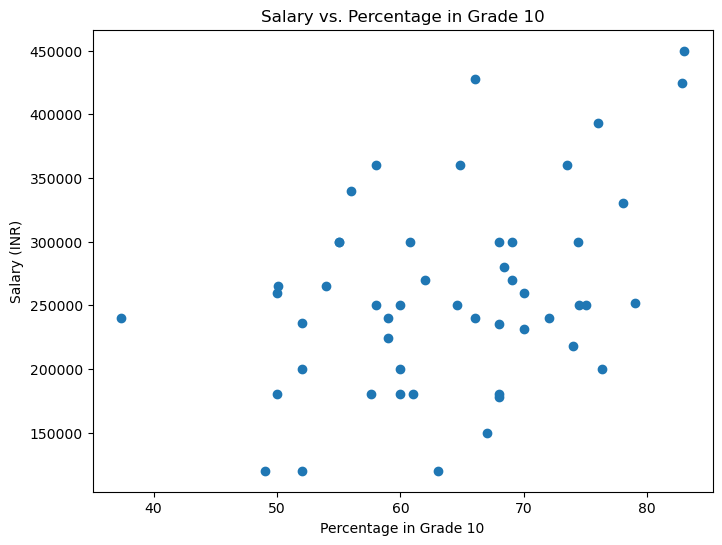

In [138]:
plt.figure(figsize=(8, 6))
plt.scatter(df['Percentage in Grade 10'], df['Salary'])
plt.title('Salary vs. Percentage in Grade 10')
plt.xlabel('Percentage in Grade 10')
plt.ylabel('Salary (INR)')
plt.show()

In [ ]:
c. Split the data appropriately into training and testing sets.

In [125]:
X = df[["Percentage in Grade 10"]]
y = df["Salary"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=44)

print(len(X_train))
print(len(X_test))

30
20


In [ ]:
d. Build the model

In [126]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
e. Perform the model diagnostics

In [127]:
#predictions
y_pred = model.predict(X_test)

In [128]:
pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

,Actual,Predicted
37,236000,215417.939590
6,260000,260118.136056
47,270000,257634.791807
36,177600,255151.447559
5,300000,222867.972334
44,360000,268809.840924
27,218000,270051.513048
33,330000,279984.890040
40,393000,275018.201544
17,280000,256144.785259


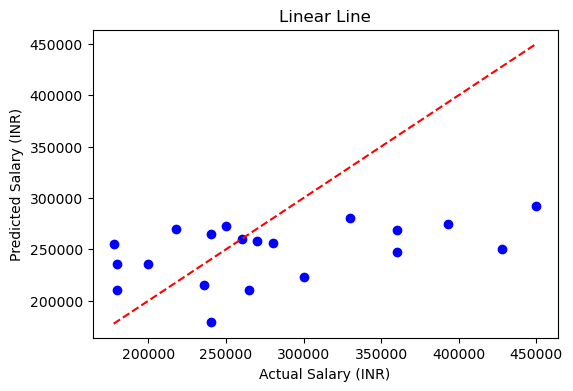

In [132]:
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred,color='blue')
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
plt.title('Linear Line')
plt.xlabel('Actual Salary (INR)')
plt.ylabel('Predicted Salary (INR)')
plt.show()

In [ ]:
f. Validate the model and measure the accuracy

In [137]:
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("MSE:", mse, "RMSE:", rmse, "MAE:", mae, "R2:", r2)

MSE: 6138796063.447011 RMSE: 78350.46945262684 MAE: 62752.734042110314 R2: 0.031340472484388426
